#  Correlation Analysis

**Period:** September 4, 2025 → February 25, 2026 (164 days)  
**Source:** Cleaned dataset from `01_data_cleaning.ipynb`

## Objectives
1. Load cleaned data
2. Compute correlations with Readiness Score
3. Identify top 3 factors impacting recovery
4. Create correlation matrix for all metrics
5. Visualize correlations with heatmap
6. Analyze relationships between metrics

**Key Questions:**
- Which metric correlates most with Readiness Score?
- Is HRV the #1 factor?
- How do sleep metrics correlate with recovery?
- Are there unexpected correlations?

In [ ]:
# IMPORTS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)

sns.set_style("whitegrid")

print("Libraries imported successfully!")
print(f"Pandas: {pd.__version__}")
print(f"Seaborn: {sns.__version__}")

Libraries imported successfully!
Pandas: 3.0.1
Seaborn: 0.13.2


In [2]:
# LOAD CLEANED DATA

# Load CSV with date as index
df = pd.read_csv('/Users/tim/Projects/custom-readiness-score/data/oura_clean.csv', index_col='date', parse_dates=True)

print(f"Data loaded: {df.shape[0]} days × {df.shape[1]} columns")

# Display period
first_date = df.index.min().strftime('%Y-%m-%d')
last_date = df.index.max().strftime('%Y-%m-%d')
print(f"Period: {first_date} → {last_date}")

print("\nFirst 5 rows:")
display(df.head())

Data loaded: 164 days × 22 columns
Period: 2025-09-04 → 2026-02-25

First 5 rows:


,Unnamed: 0,hrv,light_sleep,total_sleep,sleep_efficiency,sleep_score,temperature,readiness_score,deep_sleep,rem_sleep,rhr,total_sleep_min,deep_sleep_min,rem_sleep_min,light_sleep_min,total_sleep_h,hrv_rhr_ratio,deep_pct,rem_pct,day_of_week,day_name,weekend
date,,,,,,,,,,,,,,,,,,,,,,
2025-09-04,0,66.0,12840.0,22110.0,68.0,52,0.03,73,5850.0,3420.0,55.34,368.5,97.5,57.0,214.0,6.14,1.19,26.46,15.47,3,Thursday,False
2025-09-05,1,67.0,4350.0,10800.0,92.0,53,1.26,57,3990.0,2460.0,52.11,180.0,66.5,41.0,72.5,3.00,1.29,36.94,22.78,4,Friday,False
2025-09-06,2,58.0,10800.0,20490.0,80.0,97,0.37,84,5550.0,4140.0,61.27,341.5,92.5,69.0,180.0,5.69,0.95,27.09,20.20,5,Saturday,True
2025-09-07,3,74.0,10320.0,21420.0,77.0,82,0.35,82,6300.0,4800.0,53.92,357.0,105.0,80.0,172.0,5.95,1.37,29.41,22.41,6,Sunday,True
2025-09-08,4,39.0,10890.0,20130.0,91.0,62,0.62,37,5310.0,3930.0,71.62,335.5,88.5,65.5,181.5,5.59,0.54,26.38,19.52,0,Monday,False


In [3]:
# CORRELATIONS WITH READINESS SCORE

# Select only numeric columns
df_numeric = df.select_dtypes(include=[np.number])

correlations = df_numeric.corr()['readiness_score']
correlations_sorted = correlations.abs().sort_values(ascending=False)
correlations_sorted = correlations_sorted[correlations_sorted.index != 'readiness_score']

print("Top 10 correlations with Readiness Score:")

for i, metric in enumerate(correlations_sorted.head(10).index, 1):
    corr_actual = correlations[metric]

    if abs(corr_actual) >= 0.7:
        strength = "STRONG"
    elif abs(corr_actual) >= 0.5:
        strength = "MODERATE"
    elif abs(corr_actual) >= 0.3:
        strength = "WEAK"
    else:
        strength = "VERY WEAK"

    print(f"  {i:2d}. {metric:25s}: {corr_actual:+.3f}  ({strength})")

# Identify top 3
print("\nTOP 3 FACTORS:")
top_3 = correlations_sorted.head(3)

for i, metric in enumerate(top_3.index, 1):
    corr = correlations[metric]
    print(f"  #{i} {metric:25s}: {corr:+.3f}")


Top 10 correlations with Readiness Score:
   1. rhr                      : -0.700  (MODERATE)
   2. sleep_score              : +0.607  (MODERATE)
   3. hrv_rhr_ratio            : +0.606  (MODERATE)
   4. rem_sleep                : +0.518  (MODERATE)
   5. rem_sleep_min            : +0.518  (MODERATE)
   6. hrv                      : +0.515  (MODERATE)
   7. deep_sleep_min           : +0.495  (WEAK)
   8. deep_sleep               : +0.495  (WEAK)
   9. rem_pct                  : +0.456  (WEAK)
  10. total_sleep_min          : +0.446  (WEAK)

TOP 3 FACTORS:
  #1 rhr                      : -0.700
  #2 sleep_score              : +0.607
  #3 hrv_rhr_ratio            : +0.606


Heatmap saved to results/correlation_heatmap.png


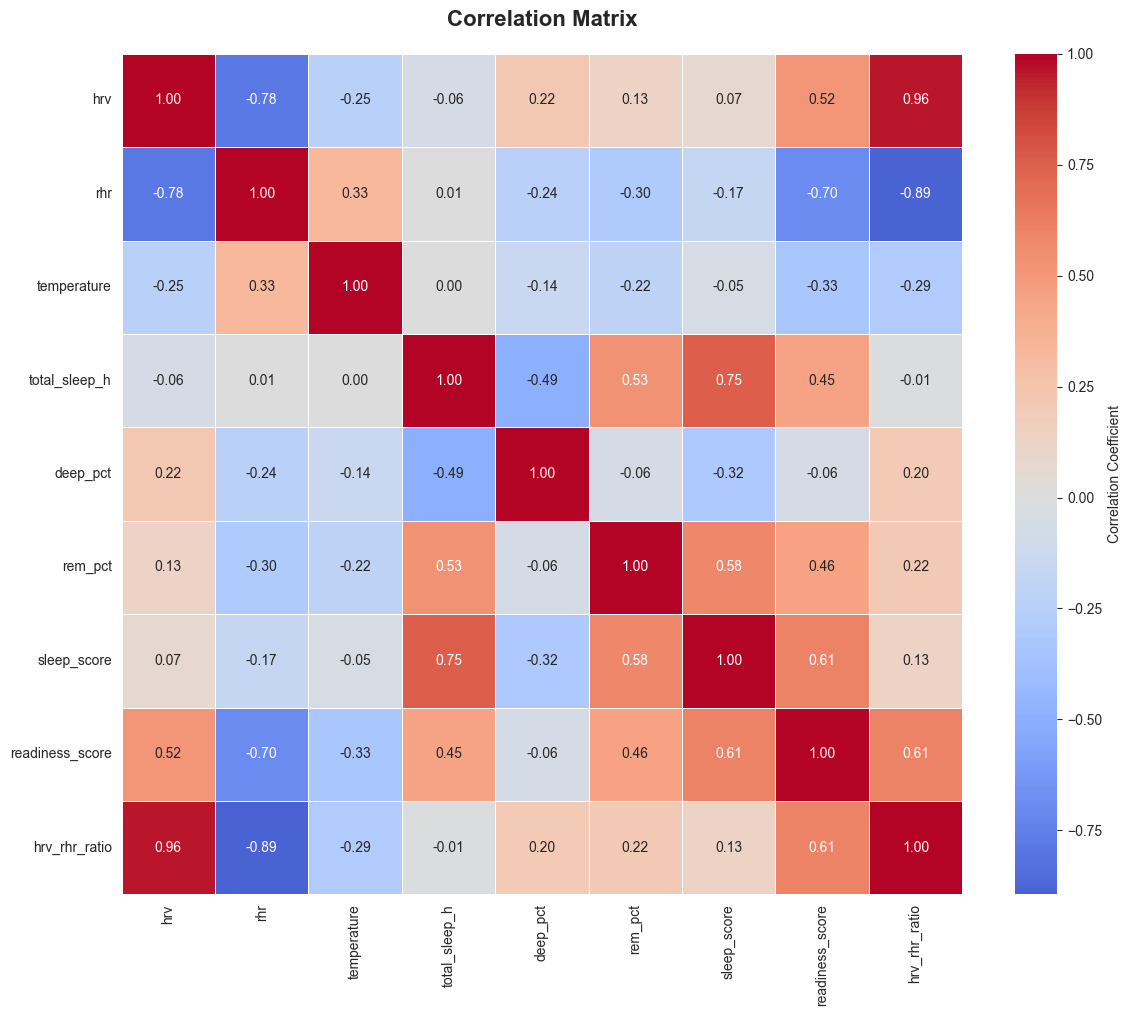

In [7]:
# CORRELATION HEATMAP

key_metrics = ['hrv', 'rhr', 'temperature', 'total_sleep_h', 'deep_pct', 'rem_pct', 'sleep_score', 'readiness_score', 'hrv_rhr_ratio']

df_subset = df[key_metrics]

correlation_matrix = df_subset.corr()

import os

# Create results directory if it doesn't exist
os.makedirs('../results', exist_ok=True)

# Create heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            square=True, linewidths=0.5,
            cbar_kws={'label': 'Correlation Coefficient'})

plt.title('Correlation Matrix', 
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()

# Save figure
plt.savefig('../results/correlation_heatmap.png', dpi=300, bbox_inches='tight')
print("Heatmap saved to results/correlation_heatmap.png")

plt.show()